# Logistic Regression

In [1]:
import sys
import os
import pandas as pd

# Agregar el directorio raiz al PYTHONPATH
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from src.trainers.train_lr import train_lr
from src.trainers.utils import build_datasets, save_metrics
from constants.constants_twitter import TWITTER_DATASET_TRAIN_PATH

dataset_train, dataset_test, dataset_val = build_datasets(
    TWITTER_DATASET_TRAIN_PATH,
    test_size=0.3,
    val_size=0.5, # 0.5 de 0.3    
    random_state=42,
    undersampling=True
)
print(dataset_train.shape)
print(dataset_test.shape)
print(dataset_val.shape)

Train: 62.08%
Test: 13.30%
Val: 13.30%
(36924, 2)
(7912, 2)
(7913, 2)


## Hiperparámetros

In [3]:
import numpy as np

list_solver_l2 = ["lbfgs", "saga"]
list_solver_l1 = ["saga"]
list_vectorizers = ["tfidf", "bow"]
list_C = np.logspace(-2, 0.7, 10)
print(list_C)

[0.01       0.01995262 0.03981072 0.07943282 0.15848932 0.31622777
 0.63095734 1.25892541 2.51188643 5.01187234]


In [4]:
best_accuracy = -1

## Penalty L2

In [5]:
from constants.constants_twitter import LR_PIPELINE_PATH, TWITTER_LR_METRICS_PATH
from src.trainers.utils import save_model

for vectorizer in list_vectorizers:
    for solver in list_solver_l2:
        for C in list_C:
            pipeline, metrics = train_lr(
                dataset_train,
                dataset_val, vec=vectorizer,
                penalty="l2", C=C, solver=solver, max_iter=1000
            )
            print(f"[LR {vectorizer} l2 {solver} {C:.2f}] acc: {metrics['accuracy']:.4f}")
            save_metrics(metrics, TWITTER_LR_METRICS_PATH)
            if metrics['accuracy'] > best_accuracy:
                best_accuracy = metrics['accuracy']
                save_model(pipeline, LR_PIPELINE_PATH)

c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LR tfidf l2 lbfgs 0.01] acc: 0.6643
Modelo guardado en: c:\Users\Diego\Desktop\sentiment_analysis\models\twitter\classifiers\lr_pipeline.pkl


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LR tfidf l2 lbfgs 0.02] acc: 0.6785
Modelo guardado en: c:\Users\Diego\Desktop\sentiment_analysis\models\twitter\classifiers\lr_pipeline.pkl


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LR bow l2 saga 2.51] acc: 0.7926


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LR bow l2 saga 5.01] acc: 0.7931


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Penalty L1

In [6]:

from constants.constants_twitter import LR_PIPELINE_PATH, TWITTER_LR_METRICS_PATH

for vectorizer in list_vectorizers:
    for solver in list_solver_l1:
        for C in list_C:
            pipeline, metrics = train_lr(
                dataset_train, dataset_val,
                vec=vectorizer, penalty="l1", C=C, solver=solver, max_iter=1000
            )
            print(f"[LR {vectorizer} l1 {solver} {C:.2f}] acc: {metrics['accuracy']:.4f}")
            save_metrics(metrics, TWITTER_LR_METRICS_PATH)
            if metrics['accuracy'] > best_accuracy:
                best_accuracy = metrics['accuracy']
                save_model(pipeline, LR_PIPELINE_PATH)

c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LR tfidf l1 saga 0.01] acc: 0.4486


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LR tfidf l1 saga 0.02] acc: 0.5253


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LR bow l1 saga 2.51] acc: 0.7824


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LR bow l1 saga 5.01] acc: 0.7887


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Modelo con mayor accurary

In [7]:
# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(TWITTER_LR_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)
print(best_accuracy)

accuracy           0.84418
recall            0.844181
precision         0.844825
f1_score           0.84422
model                   LR
vectorizer             BOW
penalty                 l2
regularization    5.011872
max_iter              1000
solver               lbfgs
vocab_size           11819
train_time        3.685371
Name: 29, dtype: object
0.8441804625300139


Cargando modelo: c:\Users\Diego\Desktop\sentiment_analysis\models\twitter\classifiers\lr_pipeline.pkl

Logistic Regression
Reporte de clasificacion
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      2667
           1       0.81      0.86      0.84      2509
           2       0.85      0.82      0.83      2736

    accuracy                           0.83      7912
   macro avg       0.83      0.84      0.83      7912
weighted avg       0.84      0.83      0.83      7912

Matriz de confusión


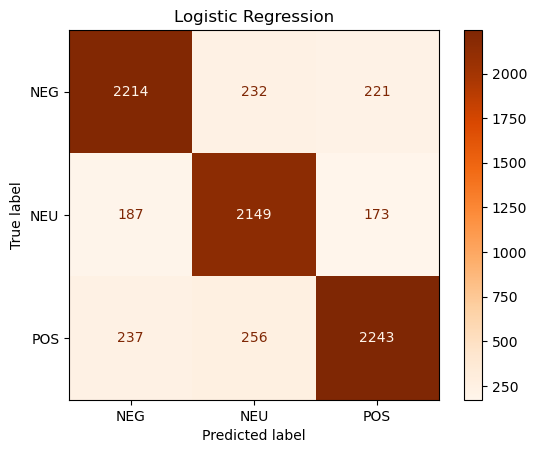

{'accuracy': 0.8349342770475228,
 'recall': 0.8349337287099114,
 'precision': 0.8354909045652891,
 'f1_score': 0.834937130820424}

In [9]:
from src.trainers.utils import evaluate_model
from src.trainers.utils import load_model

# Evaluar modelo con datos de prueba
pipeline = load_model(LR_PIPELINE_PATH)
metrics = evaluate_model(pipeline, dataset_test, title="Logistic Regression")
display(metrics)